# Theoretical relation analysis
The theoretical relation between water and sediment discharges is:
$ y [t/h]= 0,0093 x^2 + 4,2903 x - 202,1$

x in $m^3/s$
following a Jaggi relation.

In [1]:
#  imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [27]:
# import datasets

multi_scan=pd.read_csv(r"C:\Users\marga\Documents\EPFL\Cours\S3\Dranse\BASEMENT_model\Dranse_sediment\Basement-v4\Morphodynamic_multi-v4\Dranse_bnd_combined_th.dat", sep='\t', header=1, 
                       usecols=[0,1,2,4])
multi_scan.columns=['Time[s]', 'Q [m3/s]','Qsed_in tot [m3/s]', 'Qsed_out[m3/s]']
multi_scan['Qsed_out[m3/s]']=abs(multi_scan['Qsed_out[m3/s]']) # make sure sediment discharge is positive
single_scan=pd.read_csv(r"C:\Users\marga\Documents\EPFL\Cours\S3\Dranse\BASEMENT_model\Dranse_sediment\Basement-v4\Morphodynamic_single-v4\Dranse_bnd_combined_th.dat", sep='\t', header=1,
                        usecols=[0,1,2,4])
single_scan.columns=['Time[s]', 'Q [m3/s]','Qsed_in tot [m3/s]', 'Qsed_out[m3/s]']

single_scan['Qsed_out[m3/s]']=abs(single_scan['Qsed_out[m3/s]']) # make sure sediment discharge is positive

# Theoretical
# relation

def jaggi_relation(x):
    return 0.0093*x**2 + 4.2903*x - 202.1
# x in m3/s
# y in t/h

rho_sediment=2650 #kg/m3

def sediment_discharge(Q_sed):
    """Convert sediment discharge from t/h to m3/s"""
    Q_sed_m3s = Q_sed / rho_sediment / 3600
    return Q_sed_m3s



In [30]:
# theoretical sediment discharge from scan period discharge
multi_scan['Q_sed_theoretical_tph'] = jaggi_relation(multi_scan['Q [m3/s]'])
multi_scan['Q_sed_theoretical_m3s'] = sediment_discharge(multi_scan['Q_sed_theoretical_tph']).clip(lower=0) # clip negative values to 0
print(multi_scan.head())


   Time[s]   Q [m3/s]  Qsed_in tot [m3/s]  Qsed_out[m3/s]  \
0     1000  13.082000           -0.036757    0.000000e+00   
1     2000  13.082000           -0.036385    2.402516e-07   
2     3000  13.058003           -0.036082    1.557012e-06   
3     4000  13.112999           -0.035869    1.211038e-05   
4     5000  13.168330           -0.035791    7.256907e-06   

   Q_sed_theoretical_tph  Q_sed_theoretical_m3s  
0            -144.382705                    0.0  
1            -144.382705                    0.0  
2            -144.491493                    0.0  
3            -144.242158                    0.0  
4            -143.991248                    0.0  


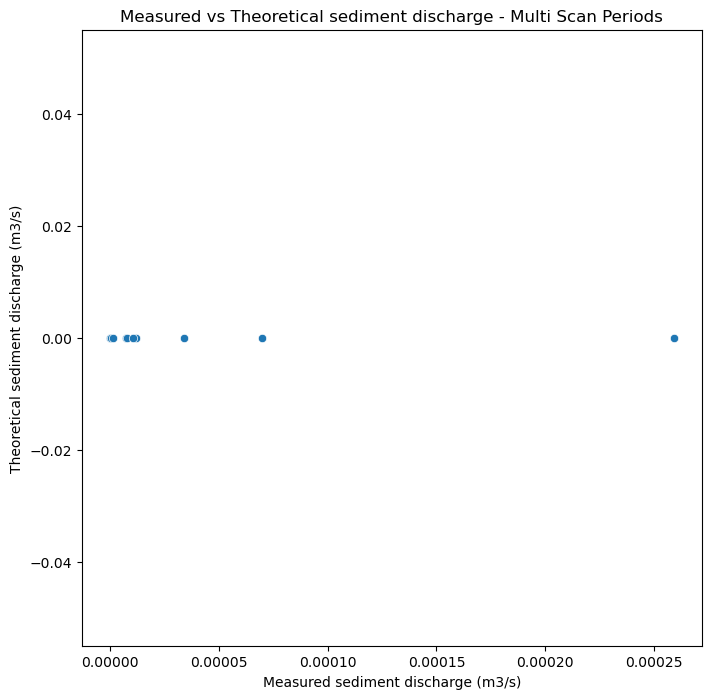

In [31]:
# QQ plots

ax, fig = plt.subplots(figsize=(8,8))
sns.scatterplot(data=multi_scan, x='Qsed_out[m3/s]', y='Q_sed_theoretical_m3s')

plt.plot(multi_scan['Q_sed_theoretical_m3s'],multi_scan['Q_sed_theoretical_m3s'], color='red', linestyle='--')
plt.xlabel('Measured sediment discharge (m3/s)')
plt.ylabel('Theoretical sediment discharge (m3/s)')
plt.title('Measured vs Theoretical sediment discharge - Multi Scan Periods')
plt.show()


In [ ]:
# total sediment volume during multi scan periods
total_sediment_volume_m3 = multi_scan['Q_sed_measured_m3s'].sum() * multi_scan['Duration_s'].sum()
print(f'Total sediment volume during multi scan periods: {total_sediment_volume_m3:.2f} m3')

theoretical_total_sediment_volume_m3 = multi_scan['Q_sed_theoretical_m3s'].sum() * multi_scan['Duration_s'].sum()
print(f'Theoretical total sediment volume during multi scan periods: {theoretical_total_sediment_volume_m3:.2f} m3')

## Sediment sizes analysis
Using flood event of 2000


In [ ]:
multi_flood=pd.read_csv('Basement_multi_flood.csv')
single_flood=pd.read_csv('Basement_single_flood.csv')

#initial sediment distribution

Sizes_classes_mm = [7, 20, 33, 46, 59] # in mm
sediment_init_percentage= [36.4, 20.6, 11.8, 16.0, 15.2] # in %

# import matrix of sediment percentages for 5 classes for each timestep
X=np.loadtxt('sediment_percentage_matrix.txt')

In [ ]:
# average sediment percentage over the flood event
average_sediment_percentage = np.mean(X, axis=0)

In [ ]:
# plot histogram of average and initial sediment distributions
fig, ax = plt.subplots(figsize=(10,6))
width = 5
ax.bar(np.array(Sizes_classes_mm)-width/2, sediment_init_percentage, width=width, label='Initial Sediment Distribution', alpha=0.7)
ax.bar(np.array(Sizes_classes_mm)+width/2, average_sediment_percentage, width=width, label='Average Sediment Distribution during Flood', alpha=0.7)
ax.set_xlabel('Sediment Size Classes (mm)')